In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian, median
import xarray as xr

import sys
sys.path.append('..')
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

In [2]:
data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/Ximea_Calibration"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [3]:
image_size = 12
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [4]:
folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Code/Python/pyBayerSMLM/Spectra/Camera_QE/'
prime95B_QE_data = pl.read_csv(os.path.join(folder, 'Prime95B.csv'), has_header=False)
prime95B_QE = np.interp(wavelength, prime95B_QE_data['column_1'], prime95B_QE_data['column_2']/100)

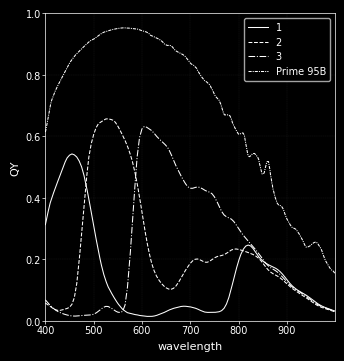

In [12]:
fig, axs = plotter.one_column_plot()
plt.style.use('dark_background')

axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs.T[:, 0], color='white', label='1')
axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs.T[:, 1], color='white', label='2', ls='--')
axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs.T[:, 2], color='white', label='3', ls='-.')

axs = plotter.line_plot(axs=axs, x=wavelength, y=prime95B_QE, color='white', yaxislabel='QY', xaxislabel='wavelength', label='Prime 95B', ls=(0, (3, 1, 1, 1)))

axs.set_ylim([0, 1])

plt.legend(loc='best')
savefolder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/setup/'
plt.savefig(os.path.join(savefolder, 'Camera_QYs.svg'), dpi=600)

In [5]:
image_size = 12
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs_nice = np.vstack([B, G, R]) * (np.max(prime95B_QE)/np.max(pixel_QYs))
nice_camera_parameters = {}
nice_camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
nice_camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
nice_camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
nice_camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
nice_camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
nice_camera_parameters["pixel_QYs"] = pixel_QYs_nice
nice_camera_parameters["pixel_order"] = ['B', 'G', 'R']
nice_camera_parameters["pixel_order_indices"] = [0, 1, 2]
nice_camera_parameters["masks"] = masks

In [6]:
fake_camera_parameters = {}
fake_camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
fake_camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
fake_camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
fake_camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
fake_camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
fake_camera_parameters["pixel_QYs"] = np.expand_dims(prime95B_QE, axis=0)
fake_camera_parameters["pixel_order"] = ['W']
fake_camera_parameters["pixel_order_indices"] = [0]
masks_fake = {}
masks_fake['W'] = np.ones_like(np.full((image_size, image_size), np.median(rqe)))
fake_camera_parameters["masks"] = masks_fake

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs.T[:, 0], color='blue', label='blue pixels')
axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs.T[:, 1], color='green', label='green pixels')
axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs.T[:, 2], color='red', label='red pixels')

axs = plotter.line_plot(axs=axs, x=wavelength, y=np.max(pixel_QYs, axis=0), color='black', yaxislabel='QY', ls='--', xaxislabel='wavelength', label='hypothetical non-colour camera')

axs = plotter.line_plot(axs=axs, x=wavelength, y=prime95B_QE, color='black', yaxislabel='QY', xaxislabel='wavelength', label='Prime 95B')

axs.set_ylim([0, 1])

plt.legend(loc='best')
savefolder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250424/fig/multicolour/compare_nocolour/'

plt.savefig(os.path.join(savefolder, 'Camera_QYs.svg'), dpi=600)

In [ ]:
n_photon_space = np.unique(np.around(np.logspace(np.log10(500), np.log10(20000), 100)/5)*5)
n_bootstrap = 1000
background_photons = 4
pixel_size = 69
NA = 1.49

In [ ]:
import types
fitter = types.SimpleNamespace()
fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "B", "G", "R"])
fitter.fit_function = I_AF.WLS_fit_colour
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [ ]:
import types
fitter_nocolour = types.SimpleNamespace()
fitter_nocolour.default_params = np.array(["xc", "yc", "A", "sigma", "b"])
fitter_nocolour.fit_function = I_AF.WLS_fit

In [ ]:
dyes = ['ATTO 488', 'ATTO 565', 'ATTO 647N', 'Alexa Fluor 488', 'Alexa Fluor 647', 'Alexa Fluor 594']
fitter.dye_library = dyes

In [ ]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di01-r405-488-561-635'
nilered_filter = 'semrock-ff01-650-200-25'
shortpass_filter = 'semrock-bsp01-785r'
filters = [notch_filter, dichroic_mirror, shortpass_filter]

In [ ]:
save_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20250425_ComparingColourtoPrime95B'
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

In [ ]:
for dye in dyes:
    print("Analysing dye {}, + colour info".format(dye), end="\r",flush=True,)        
    MSF.test_single_fit_method(
                        dye,
                        filters,
                        wavelength,
                        nice_camera_parameters,
                        fitter,
                        smoothing_function,
                        save_folder,
                        n_photon_space,
                        n_bootstrap=n_bootstrap,
                        background_photons=background_photons,
                        NA=NA,
                        pixel_size=pixel_size,
                        cpu_fraction=1,
                    )

In [7]:
results_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20250404_ComparingColourtoNot/'

In [8]:
files = os.listdir(results_folder)
files_nocolour = np.sort([x for x in files if 'fitter_WLS_fit_smoothingfunction' in x and 'std' in x])
files_colour = np.sort([x for x in files if 'fitter_WLS_fit_colour_smoothingfunction' in x and 'std' in x])


In [9]:
results_folder_prime95B = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20250424_ComparingColourtoPrime95B'


In [10]:
files = os.listdir(results_folder_prime95B)
files_prime95bnocolour = np.sort([x for x in files if 'fitter_WLS_fit_smoothingfunction' in x and 'std' in x])

In [11]:
results_folder_nicecam = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20250425_ComparingColourtoPrime95B'
files = os.listdir(results_folder_nicecam)
files_nicecam = np.sort([x for x in files if 'fitter_WLS_fit_colour_smoothingfunction' in x and 'std' in x])

In [12]:
file_zero = pl.read_csv(os.path.join(results_folder, files_nocolour[0]))

In [13]:
photons = file_zero['n_photons'].to_numpy()
errors = np.zeros_like(file_zero['xc'].to_numpy())

for file in files_nocolour:
    errors += pl.read_csv(os.path.join(results_folder, file))['xc'].to_numpy()
errors = errors/len(files_nocolour)

In [14]:
photons = file_zero['n_photons'].to_numpy()
errors_p95B = np.zeros_like(file_zero['xc'].to_numpy())

for file in files_prime95bnocolour:
    errors_p95B += pl.read_csv(os.path.join(results_folder_prime95B, file))['xc'].to_numpy()
errors_p95B = errors_p95B/len(files_prime95bnocolour)

In [15]:
photons = file_zero['n_photons'].to_numpy()
errors_c = np.zeros_like(file_zero['xc'].to_numpy())

for file in files_colour:
    errors_c += pl.read_csv(os.path.join(results_folder, file))['xc'].to_numpy()
errors_c = errors_c/len(files_colour)

In [16]:
photons = file_zero['n_photons'].to_numpy()
errors_n = np.zeros_like(file_zero['xc'].to_numpy())

for file in files_nicecam:
    errors_n += pl.read_csv(os.path.join(results_folder_nicecam, file))['xc'].to_numpy()
errors_n = errors_n/len(files_nicecam)

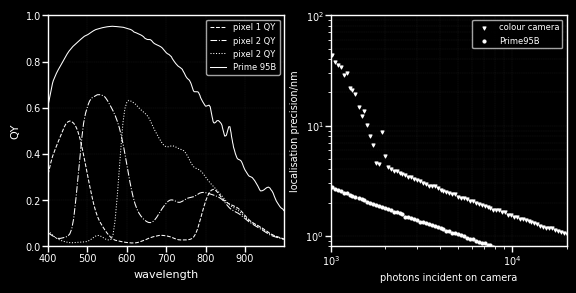

In [55]:
fig, ax = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])
axs = ax[0]


axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs.T[:, 0], color='white', label='pixel 1 QY', ls='--')
axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs.T[:, 1], color='white', label='pixel 2 QY', ls='-.')
axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs.T[:, 2], color='white', label='pixel 2 QY', ls=':')

#axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs_nice.T[:, 0], color='blue', ls='--')
#axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs_nice.T[:, 1], color='green', ls='--')
#axs = plotter.line_plot(axs=axs, x=wavelength, y=pixel_QYs_nice.T[:, 2], color='red', ls='--')


#axs = plotter.line_plot(axs=axs, x=wavelength, y=np.max(pixel_QYs, axis=0), color='white', alpha=0.3, lw=5,
#                        yaxislabel='QY', xaxislabel='wavelength', label='hypothetical non-colour camera')

axs = plotter.line_plot(axs=axs, x=wavelength, y=prime95B_QE, color='white', yaxislabel='QY', xaxislabel='wavelength', label='Prime 95B')

axs.set_ylim([0, 1])

axs.legend(loc='best', fontsize=6)

cs = ["#ca6152",
"#8ea042",
"#4cac9a",
"#a16abc"]

#ax[1] = plotter.scatter_plot(axs=ax[1], x=photons, y=errors, label='hypothetical non-colour camera', facecolor=cs[0], edgecolor=None)
ax[1] = plotter.scatter_plot(axs=ax[1], x=photons, y=errors_c, xaxislabel='photons incident on camera',
                            yaxislabel='localisation precision/nm', label='colour camera', marker='v', facecolor='white', edgecolor=None)

ax[1] = plotter.scatter_plot(axs=ax[1], x=photons, y=errors_p95B, xaxislabel='photons incident on camera',
                            yaxislabel='localisation precision/nm', label='Prime95B', facecolor='white', edgecolor=None)

#ax[1] = plotter.scatter_plot(axs=ax[1], x=photons, y=errors_n, xaxislabel='photons incident on camera',
#                            yaxislabel='localisation precision/nm', label='hypothetical colour camera', marker='v', facecolor=cs[3], edgecolor=None)

ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_ylim([0.8, 100])
ax[1].set_xlim([1e3, 2e4])
ax[1].legend(loc='best', fontsize=6)
plt.style.use('dark_background')


savefolder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250522/fig/multicolour/compare_nocolour/'

plt.savefig(os.path.join(savefolder, 'Colour_NoColour_Comp_BW.svg'), dpi=600)

(0.0, 5.0)

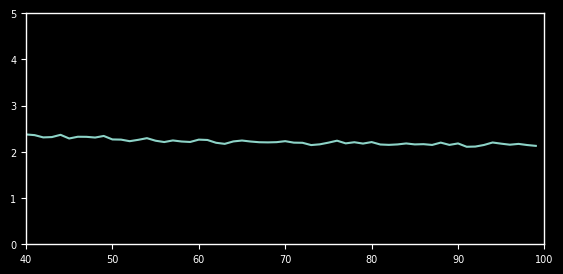

In [43]:
plt.plot(errors_c/errors_p95B)
plt.xlim([40, 100])
plt.ylim([0, 5])

In [49]:
performance_degradation = errors_c/errors_p95B

(array([64.,  2.,  1.,  2.,  1.,  2.,  0.,  0.,  2.,  1.,  0.,  1.,  1.,
         0.,  2.,  2.,  1.,  2.,  0.,  0.,  2.,  0.,  1.,  2.,  1.,  2.,
         0.,  3.,  2.,  3.]),
 array([ 2.11042823,  2.90012664,  3.68982506,  4.47952347,  5.26922189,
         6.05892031,  6.84861872,  7.63831714,  8.42801555,  9.21771397,
        10.00741238, 10.7971108 , 11.58680921, 12.37650763, 13.16620604,
        13.95590446, 14.74560287, 15.53530129, 16.3249997 , 17.11469812,
        17.90439653, 18.69409495, 19.48379336, 20.27349178, 21.06319019,
        21.85288861, 22.64258702, 23.43228544, 24.22198386, 25.01168227,
        25.80138069]),
 <BarContainer object of 30 artists>)

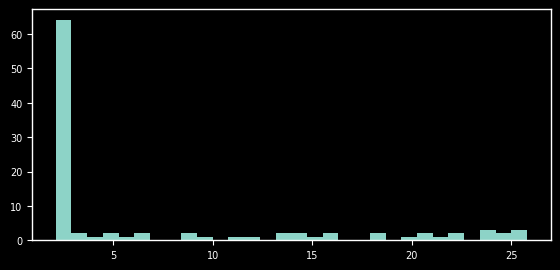

In [51]:
plt.hist(performance_degradation, 30)

In [53]:
np.median(performance_degradation)

2.293335685699256